In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
df=sns.load_dataset('penguins')

In [100]:
df.shape

(344, 7)

In [101]:
df.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


In [102]:
df.species.value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [103]:
df.groupby(['species','island']).agg({'island': 'count'})

island
species   island           
Adelie    Biscoe         44
          Dream          56
          Torgersen      52
Chinstrap Dream          68
Gentoo    Biscoe        124

In [104]:
## Encoding "species"
species=list(df.species.unique())
species

['Adelie', 'Chinstrap', 'Gentoo']

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

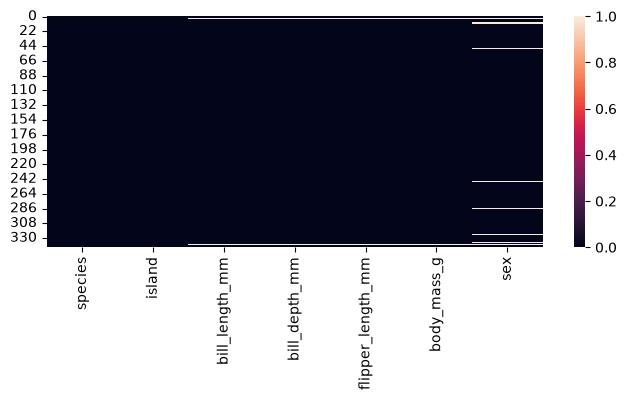

In [106]:
plt.figure(figsize=(8,3))
sns.heatmap(df.isnull())
plt.show()

In [107]:
df['sex']=df['sex'].ffill()

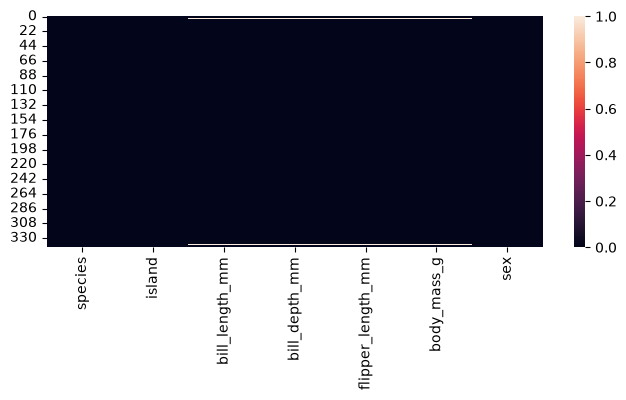

In [108]:
plt.figure(figsize=(8,3))
sns.heatmap(df.isnull())
plt.show()

In [109]:
df=df.dropna()

In [110]:
df.shape

(342, 7)

In [111]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [112]:
df.info()

<class 'pandas.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    str    
 1   island             342 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                342 non-null    str    
dtypes: float64(4), str(3)
memory usage: 27.4 KB


In [113]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [114]:
import numpy as np

In [115]:
df.select_dtypes(include=np.number).columns

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='str')

In [116]:
for col in df.select_dtypes(include=np.number).columns:
    print(col)

bill_length_mm
bill_depth_mm
flipper_length_mm
body_mass_g


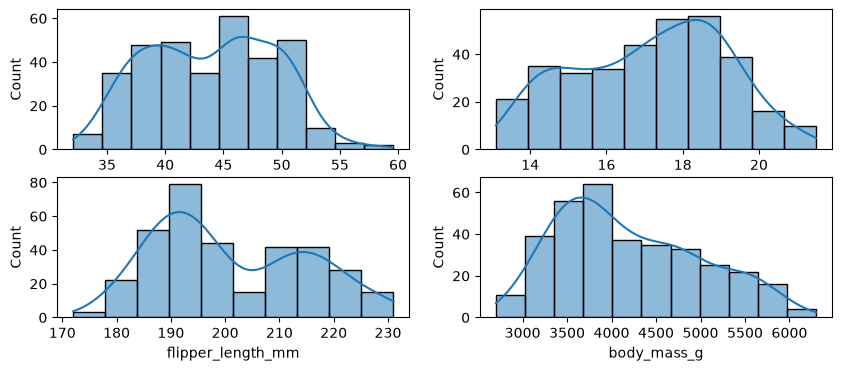

In [117]:
## checking outlier in dataset
plt.figure(figsize=(10,4))
i=1
for col in df.select_dtypes(include=np.number).columns:
    plt.subplot(2,2,i)
    sns.histplot(x=col, data=df, kde=True)
    i=i+1
plt.show()
    

In [96]:
## Encode "species" y(target) feature 
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder(categories=[species])

In [97]:
df['species']=encoder.fit_transform(df[['species']])

In [75]:
df.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0.0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,0.0,Torgersen,39.5,17.4,186.0,3800.0,Female
2,0.0,Torgersen,40.3,18.0,195.0,3250.0,Female


In [118]:
## Encoding in another way
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female


In [119]:
df['species']=df['species'].map(lambda val: species.index(val))

In [121]:
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,0,Torgersen,39.5,17.4,186.0,3800.0,Female


In [122]:
## divided data into x(data) and y(feature)

In [123]:
x=df.drop(columns=['species'])
y=df['species']

In [124]:
x.head(2)

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Torgersen,39.5,17.4,186.0,3800.0,Female


In [125]:
## Prepare x(data) for training
## Encoding
from sklearn.preprocessing import LabelEncoder

In [127]:
encoder=LabelEncoder()

In [128]:
df.select_dtypes(include=str).columns

Index(['island', 'sex'], dtype='str')

In [131]:
for col in x.select_dtypes(include=str).columns:
    x[col]=encoder.fit_transform(x[col])

In [132]:
x.head(3)

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,39.1,18.7,181.0,3750.0,1
1,2,39.5,17.4,186.0,3800.0,0
2,2,40.3,18.0,195.0,3250.0,0


In [134]:
## scalling x(data) for model training
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [135]:
x.select_dtypes(include=float).columns

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='str')

In [136]:
for col in x.select_dtypes(include=float).columns:
    x[col]=scaler.fit_transform(x[[col]])

In [137]:
x.head(3)

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,0.254545,0.666667,0.152542,0.291667,1
1,2,0.269091,0.511905,0.237288,0.305556,0
2,2,0.298182,0.583333,0.389831,0.152778,0


In [138]:
## divided data/target into train and testing
from sklearn.model_selection import train_test_split

In [139]:
x_train,x_test, y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=41)

In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [146]:
models={
        'Logistic Regression' : LogisticRegression(),
        'Support Vector Classifier' : SVC(),
        'Random Forest Classifier' : RandomForestClassifier(),
        'Decision Tree Classifier' : DecisionTreeClassifier()    
}

In [148]:
from sklearn.metrics import accuracy_score

In [149]:
## start training and model Evaluation 
for name,model in models.items():
    model.fit(x_train, y_train)
    y_pre=model.predict(x_test)
    print(f"Model : {name}\t Accuracy Score : {accuracy_score(y_test,y_pre)*100}")

Model : Logistic Regression	 Accuracy Score : 95.65217391304348
Model : Support Vector Classifier	 Accuracy Score : 100.0
Model : Random Forest Classifier	 Accuracy Score : 98.55072463768117
Model : Decision Tree Classifier	 Accuracy Score : 95.65217391304348
